# 02: Feature Engineering - Smart Grid Load Forecasting

## Objective
Create temporal and cyclic features from the datetime index to capture time-based patterns in electricity load.

## Tasks
- Create calendar features (hour, day_of_week, month, weekend_flag)
- Create cyclic encoding (sin_hour, cos_hour, sin_month, cos_month)
- Visualize feature correlations
- Create heatmap of feature importance

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 1: Load Processed Data

In [2]:
# Load the processed data
df = pd.read_csv('../data/AEP_processed.csv', index_col='Datetime', parse_dates=True)

print('Data loaded successfully!')
print(f'Shape: {df.shape}')
print(f'\nFirst few rows:')
print(df.head())

Data loaded successfully!
Shape: (121273, 1)

First few rows:
                      AEP_MW
Datetime                    
2004-12-31 01:00:00  13478.0
2004-12-31 02:00:00  12865.0
2004-12-31 03:00:00  12577.0
2004-12-31 04:00:00  12517.0
2004-12-31 05:00:00  12670.0


## Step 2: Create Calendar Features

### Why Calendar Features?
Electricity load has strong temporal patterns:
- Different hours have peak and off-peak periods
- Weekdays vs weekends have different load profiles
- Months show seasonal variations

These features help the model capture these periodic patterns.

In [3]:
# Create calendar features
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek  # 0=Monday, 6=Sunday
df['month'] = df.index.month  # 1-12
df['day_of_year'] = df.index.dayofyear  # 1-365

# Weekend flag (1 = weekend, 0 = weekday)
df['weekend_flag'] = (df['day_of_week'] >= 5).astype(int)

# Quarter (1-4)
df['quarter'] = df.index.quarter

print('Calendar features created!')
print(f'\nShape after adding features: {df.shape}')
print(f'\nFeatures added:')
print(df.head(48))  # Show 2 days of data

Calendar features created!

Shape after adding features: (121273, 7)

Features added:
                      AEP_MW  hour  day_of_week  month  day_of_year  \
Datetime                                                              
2004-12-31 01:00:00  13478.0     1            4     12          366   
2004-12-31 02:00:00  12865.0     2            4     12          366   
2004-12-31 03:00:00  12577.0     3            4     12          366   
2004-12-31 04:00:00  12517.0     4            4     12          366   
2004-12-31 05:00:00  12670.0     5            4     12          366   
2004-12-31 06:00:00  13038.0     6            4     12          366   
2004-12-31 07:00:00  13692.0     7            4     12          366   
2004-12-31 08:00:00  14297.0     8            4     12          366   
2004-12-31 09:00:00  14719.0     9            4     12          366   
2004-12-31 10:00:00  14941.0    10            4     12          366   
2004-12-31 11:00:00  15184.0    11            4     12        

## Step 3: Create Cyclic Features

### Why Cyclic Encoding?
Calendar features like hour and month are circular (hour 23 is close to hour 0).
Linear encoding would treat them incorrectly.

**Solution:** Use sine and cosine transformation:
- sin(2π * feature / max_value)
- cos(2π * feature / max_value)

This preserves the circular nature and prevents boundary issues.

In [4]:
# Cyclic encoding for hour
df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)

# Cyclic encoding for month
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# Cyclic encoding for day of week
df['sin_day'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['cos_day'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Cyclic encoding for day of year
df['sin_year'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['cos_year'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

print('Cyclic features created!')
print(f'\nShape after cyclic encoding: {df.shape}')
print(f'\nFeatures:')
print(df.columns.tolist())

Cyclic features created!

Shape after cyclic encoding: (121273, 15)

Features:
['AEP_MW', 'hour', 'day_of_week', 'month', 'day_of_year', 'weekend_flag', 'quarter', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'sin_day', 'cos_day', 'sin_year', 'cos_year']


## Step 4: Visualize Cyclic Encoding

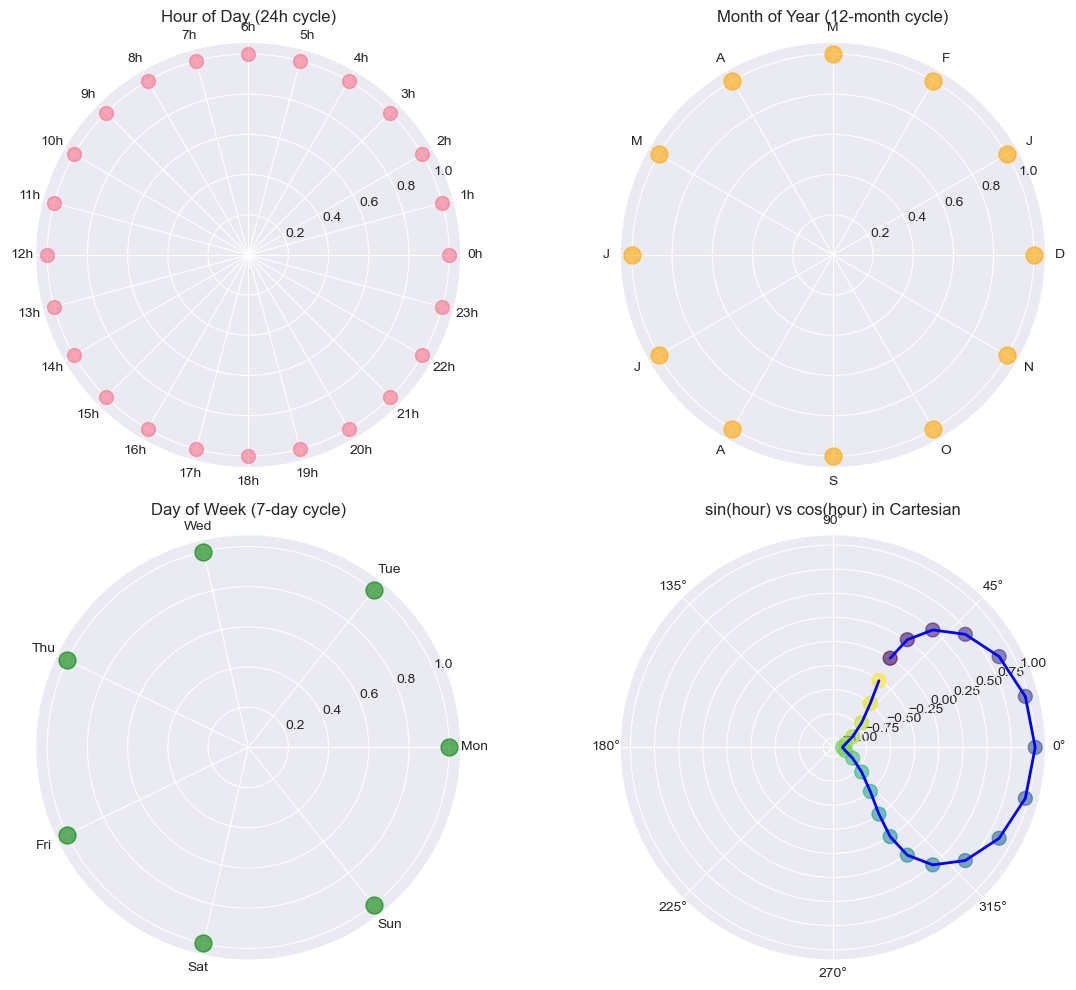

Cyclic encoding visualizations created!


In [9]:
# Create circular plots to show the cyclic encoding
fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw=dict(projection='polar'))

# Hour cycle
hours = np.arange(0, 24)
sin_h = np.sin(2 * np.pi * hours / 24)
cos_h = np.cos(2 * np.pi * hours / 24)
angles_h = 2 * np.pi * hours / 24

axes[0, 0].scatter(angles_h, np.ones(24), s=100, alpha=0.6)
axes[0, 0].set_title('Hour of Day (24h cycle)', pad=15)
axes[0, 0].set_xticks(np.linspace(0, 2*np.pi, 24, endpoint=False))
axes[0, 0].set_xticklabels([f'{h}h' for h in range(24)])

# Month cycle
months = np.arange(1, 13)
angles_m = 2 * np.pi * months / 12
axes[0, 1].scatter(angles_m, np.ones(12), s=150, alpha=0.6, color='orange')
axes[0, 1].set_title('Month of Year (12-month cycle)', pad=15)
axes[0, 1].set_xticks(angles_m)
axes[0, 1].set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])

# Day of week cycle
days_num = np.arange(0, 7)
angles_d = 2 * np.pi * days_num / 7
axes[1, 0].scatter(angles_d, np.ones(7), s=150, alpha=0.6, color='green')
axes[1, 0].set_title('Day of Week (7-day cycle)', pad=15)
axes[1, 0].set_xticks(angles_d)
axes[1, 0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

# Show sin/cos representation for hour
axes[1, 1].plot(cos_h, sin_h, 'b-', linewidth=2)
axes[1, 1].scatter(cos_h, sin_h, s=100, alpha=0.6, c=hours, cmap='viridis')
axes[1, 1].set_title('sin(hour) vs cos(hour) in Cartesian', pad=15)

plt.tight_layout()
plt.show()

print('Cyclic encoding visualizations created!')

## Step 5: Complete Feature List

In [10]:
# Display all features
print('All Features Created:')
print('='*50)

feature_categories = {
    'Target': ['AEP_MW'],
    'Calendar (Linear)': ['hour', 'day_of_week', 'month', 'day_of_year', 'quarter'],
    'Binary': ['weekend_flag'],
    'Cyclic (Sine-Cosine pairs)': [
        'sin_hour', 'cos_hour',
        'sin_day', 'cos_day',
        'sin_month', 'cos_month',
        'sin_year', 'cos_year'
    ]
}

for category, features in feature_categories.items():
    print(f'\n{category}:')
    for feat in features:
        print(f'  - {feat}')

print(f'\n\nTotal features: {len(df.columns)}')
print(f'Total rows: {len(df)}')

All Features Created:

Target:
  - AEP_MW

Calendar (Linear):
  - hour
  - day_of_week
  - month
  - day_of_year
  - quarter

Binary:
  - weekend_flag

Cyclic (Sine-Cosine pairs):
  - sin_hour
  - cos_hour
  - sin_day
  - cos_day
  - sin_month
  - cos_month
  - sin_year
  - cos_year


Total features: 15
Total rows: 121273


## Step 6: Correlation Analysis

Correlation with AEP_MW (electricity load):
AEP_MW          1.000000
hour            0.419480
sin_day         0.228370
cos_year        0.141280
cos_month       0.133416
sin_month       0.052056
sin_year        0.008321
cos_day        -0.061511
day_of_year    -0.124299
month          -0.125545
quarter        -0.134911
day_of_week    -0.219467
cos_hour       -0.232767
weekend_flag   -0.266815
sin_hour       -0.397234
Name: AEP_MW, dtype: float64


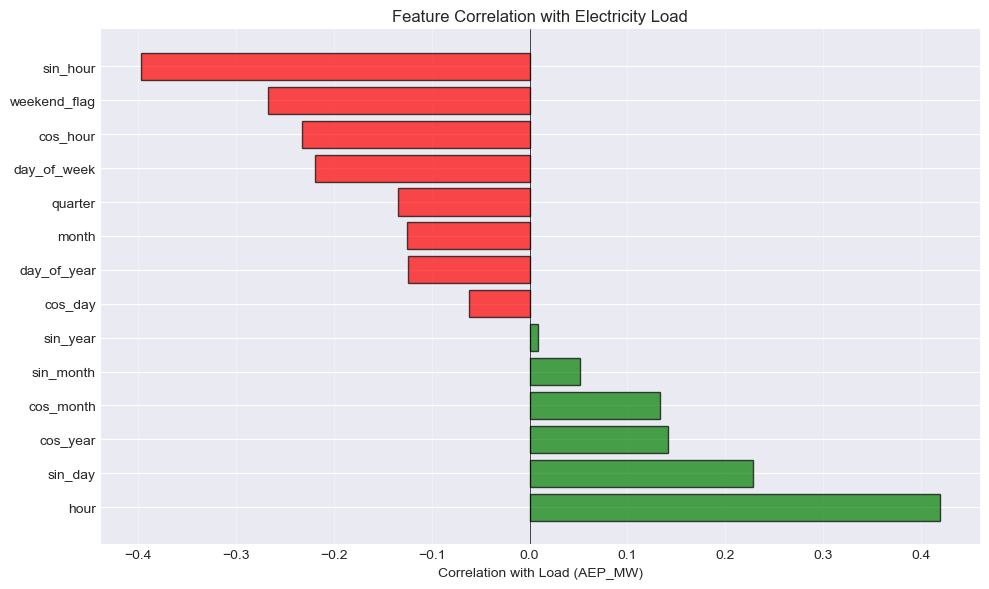

In [11]:
# Calculate correlation with target variable
correlation = df.corr()['AEP_MW'].sort_values(ascending=False)

print('Correlation with AEP_MW (electricity load):')
print('='*50)
print(correlation)

# Plot correlation
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in correlation[1:]]
ax.barh(range(len(correlation)-1), correlation[1:], color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(correlation)-1))
ax.set_yticklabels(correlation.index[1:])
ax.set_xlabel('Correlation with Load (AEP_MW)')
ax.set_title('Feature Correlation with Electricity Load')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Step 7: Feature Correlation Heatmap

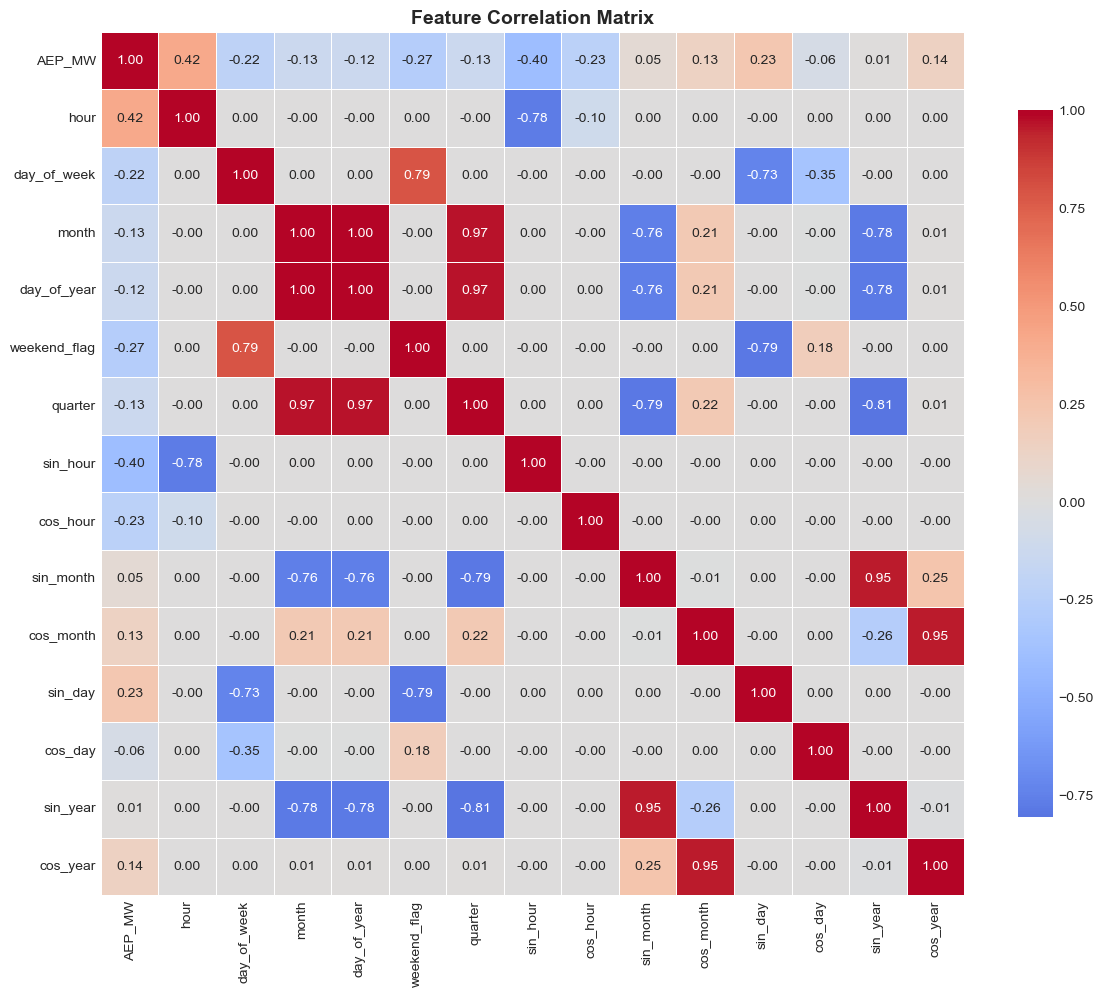

Correlation heatmap created!


In [12]:
# Calculate full correlation matrix
corr_matrix = df.corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation heatmap created!')

## Step 8: Key Feature Insights

In [17]:
# Analyze which features are most important
print('\nKey Feature Insights:')
print('='*60)

# Most correlated features with load
top_features = correlation.abs().sort_values(ascending=False)[1:6]
print('\nTop 5 Most Correlated Features:')
for i, (feat, corr) in enumerate(top_features.items(), 1):
    print(f'{i}. {feat:15s} -> correlation: {correlation[feat]:+.4f}')

print('\n\nInterpretation:')
print('-' * 60)

# Dynamic interpretation based on actual top features
top_feature_names = set(top_features.index)

if 'hour' in top_feature_names:
    print('• hour: Linear hour feature is strongest predictor')
if 'sin_hour' in top_feature_names or 'cos_hour' in top_feature_names:
    print('• sin_hour & cos_hour: Daily load cycle patterns detected')
if 'sin_year' in top_feature_names or 'cos_year' in top_feature_names:
    print('• sin_year & cos_year: Seasonal patterns are significant')
if 'weekend_flag' in top_feature_names:
    print('• weekend_flag: Weekend/weekday distinction matters')
if 'sin_day' in top_feature_names or 'cos_day' in top_feature_names:
    print('• sin_day & cos_day: Day-of-week patterns exist')

print('\nNote: Features not in top 5 may have lower direct correlation')
print('but can still be valuable for model performance through')
print('interactions and non-linear relationships.')


Key Feature Insights:

Top 5 Most Correlated Features:
1. hour            -> correlation: +0.4195
2. sin_hour        -> correlation: -0.3972
3. weekend_flag    -> correlation: -0.2668
4. cos_hour        -> correlation: -0.2328
5. sin_day         -> correlation: +0.2284


Interpretation:
------------------------------------------------------------
• hour: Linear hour feature is strongest predictor
• sin_hour & cos_hour: Daily load cycle patterns detected
• weekend_flag: Weekend/weekday distinction matters
• sin_day & cos_day: Day-of-week patterns exist

Note: Features not in top 5 may have lower direct correlation
but can still be valuable for model performance through
interactions and non-linear relationships.


## Summary

### Features Created:

**Calendar Features (Linear):**
- `hour`: 0-23
- `day_of_week`: 0-6 (0=Monday)
- `month`: 1-12
- `day_of_year`: 1-365
- `quarter`: 1-4

**Binary Features:**
- `weekend_flag`: 1 if Saturday/Sunday, 0 otherwise

**Cyclic Features (Sine-Cosine Pairs):**
- `sin_hour`, `cos_hour`: Captures 24-hour periodicity
- `sin_day`, `cos_day`: Captures 7-day periodicity
- `sin_month`, `cos_month`: Captures 12-month periodicity
- `sin_year`, `cos_year`: Captures annual seasonality

### Why Cyclic Encoding?
Time features are circular (hour 23 is close to hour 0). Sine-cosine transformation preserves this circular nature, making it perfect for temporal features.

### Next Steps:
- Normalize all features
- Create sequences for time series models
- Split data into train/validation/test sets

In [18]:
# Save engineered features for next notebook
df.to_csv('../data/AEP_engineered.csv')
print('Engineered features saved to ../data/AEP_engineered.csv')
print(f'Final shape: {df.shape}')
print(f'\nFeatures: {list(df.columns)}')

Engineered features saved to ../data/AEP_engineered.csv
Final shape: (121273, 15)

Features: ['AEP_MW', 'hour', 'day_of_week', 'month', 'day_of_year', 'weekend_flag', 'quarter', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'sin_day', 'cos_day', 'sin_year', 'cos_year']
